# Notebook 04 — Customer RFM Segmentation

---

**Business Question:** Who are our most valuable customers, and what should we do differently for each group?  
**Why this matters:** Treating all customers identically wastes marketing budget and misses opportunities. A small segment of customers typically drives the majority of revenue — identifying them enables targeted retention before they churn.  
**Data used:** Clean retail dataset — 2009–2011 transactions. Snapshot date: 2011-12-31

---

### What this notebook does
1. Calculate Recency, Frequency, Monetary (RFM) metrics per customer
2. Score each customer on a 1–4 scale per dimension
3. Assign to one of 5 business-meaningful segments
4. Visualise segment distribution and revenue contribution
5. Present an action table with a recommended next step per segment (日本語)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def _jp_font():
    for name in ['Yu Gothic', 'Meiryo', 'MS Gothic']:
        p = fm.findfont(fm.FontProperties(family=name), fallback_to_default=False)
        if p and 'DejaVu' not in p:
            return name
    return 'sans-serif'

PALETTE = ['#2C7BB6', '#D7191C', '#ABDDA4', '#FDAE61', '#4DAC26']
SEGMENT_COLORS = {
    'Champions':        '#2C7BB6',
    'Loyal Customers':  '#4DAC26',
    'At Risk':          '#FDAE61',
    'Lost':             '#D7191C',
    'New Customers':    '#ABDDA4',
}
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': _jp_font(),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

df = pd.read_csv('../data/clean_retail.csv', parse_dates=['InvoiceDate'])
SNAPSHOT_DATE = pd.Timestamp('2011-12-31')
print(f'Loaded {len(df):,} rows | {df["Customer ID"].nunique():,} unique customers')
print(f'Snapshot date for Recency: {SNAPSHOT_DATE.date()}')

Loaded 805,549 rows | 5,878 unique customers
Snapshot date for Recency: 2011-12-31


## Step 1 — Calculate RFM Metrics

| Metric | Definition |
|---|---|
| **Recency** | Days since last purchase (lower = more recent = better) |
| **Frequency** | Number of distinct invoices (higher = more engaged) |
| **Monetary** | Total revenue contributed (higher = more valuable) |

In [2]:
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (SNAPSHOT_DATE - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(f'RFM table: {len(rfm):,} customers')
print(rfm.describe().round(1).to_string())

RFM table: 5,878 customers
       Customer ID  Recency  Frequency  Monetary
count       5878.0   5878.0     5878.0    5878.0
mean       15315.3    221.9        6.3    3018.6
std         1715.6    209.4       13.0   14737.7
min        12346.0     21.0        1.0       3.0
25%        13833.2     46.0        1.0     348.8
50%        15314.5    116.0        3.0     898.9
75%        16797.8    400.0        7.0    2307.1
max        18287.0    759.0      398.0  608821.6


## Step 2 — Score Each Dimension (Quartile-Based, 1–4)

Score 4 = best. For Recency, lower days = score 4 (more recent is better).

In [3]:
def quartile_score(series, ascending=True):
    scored = pd.qcut(series.rank(method='first'), q=4, labels=False) + 1
    if not ascending:
        scored = 5 - scored
    return scored.astype(int)

rfm['R_Score'] = quartile_score(rfm['Recency'], ascending=False)  # low recency = good
rfm['F_Score'] = quartile_score(rfm['Frequency'], ascending=True)
rfm['M_Score'] = quartile_score(rfm['Monetary'], ascending=True)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print('Score distribution:')
print(rfm[['R_Score', 'F_Score', 'M_Score', 'RFM_Score']].describe().round(1).to_string())

Score distribution:
       R_Score  F_Score  M_Score  RFM_Score
count   5878.0   5878.0   5878.0     5878.0
mean       2.5      2.5      2.5        7.5
std        1.1      1.1      1.1        2.9
min        1.0      1.0      1.0        3.0
25%        1.2      1.2      1.2        5.0
50%        2.5      2.5      2.5        7.0
75%        3.8      3.8      3.8       10.0
max        4.0      4.0      4.0       12.0


## Step 3 — Assign Business Segments

Five segments are defined using RFM score thresholds that are meaningful in a retail context.

In [4]:
def assign_segment(row):
    r, f, m, total = row['R_Score'], row['F_Score'], row['M_Score'], row['RFM_Score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'New Customers'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

seg_summary = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Revenue=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(1)
seg_summary['Revenue_%'] = (seg_summary['Total_Revenue'] / seg_summary['Total_Revenue'].sum() * 100).round(1)
seg_summary['Customer_%'] = (seg_summary['Customers'] / seg_summary['Customers'].sum() * 100).round(1)
print(seg_summary.to_string())

                 Customers  Avg_Recency  Avg_Frequency  Avg_Revenue  Total_Revenue  Revenue_%  Customer_%
Segment                                                                                                  
At Risk                888        296.0            6.5       2524.3      2241556.6       12.6        15.1
Champions             1807         49.6           14.1       7440.0     13443999.8       75.8        30.7
Lost                   774        560.5            1.0        329.6       255141.8        1.4        13.2
Loyal Customers        798         56.3            2.8        988.4       788758.4        4.4        13.6
New Customers         1611        293.5            1.6        629.4      1013972.6        5.7        27.4


## Step 4 — Visualise: Customer Count by Segment

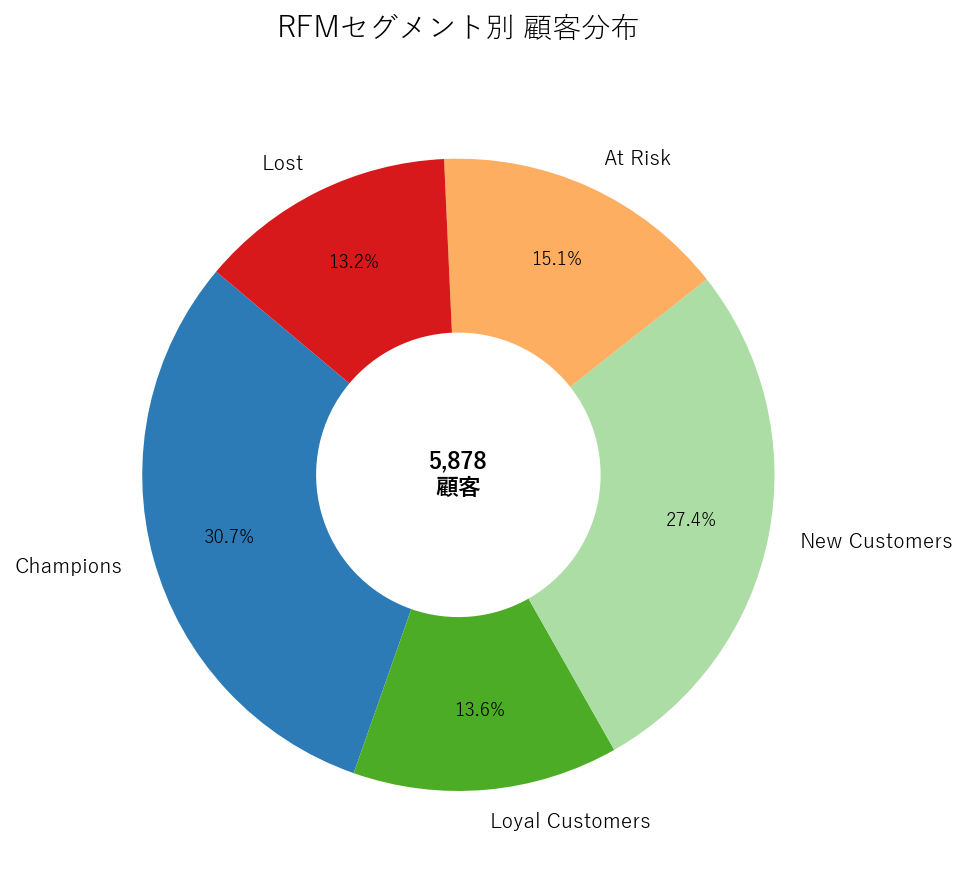

In [5]:
seg_order = ['Champions', 'Loyal Customers', 'New Customers', 'At Risk', 'Lost']
counts = rfm['Segment'].value_counts().reindex(seg_order, fill_value=0)
colors_pie = [SEGMENT_COLORS[s] for s in counts.index]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    wedgeprops=dict(width=0.55),
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)

ax.set_title('RFMセグメント別 顧客分布', fontsize=14, pad=20)
centre_text = f'{len(rfm):,}\n顧客'
ax.text(0, 0, centre_text, ha='center', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/charts/rfm_segment_distribution.png', bbox_inches='tight')
plt.show()

## Step 5 — Visualise: Revenue Contribution by Segment

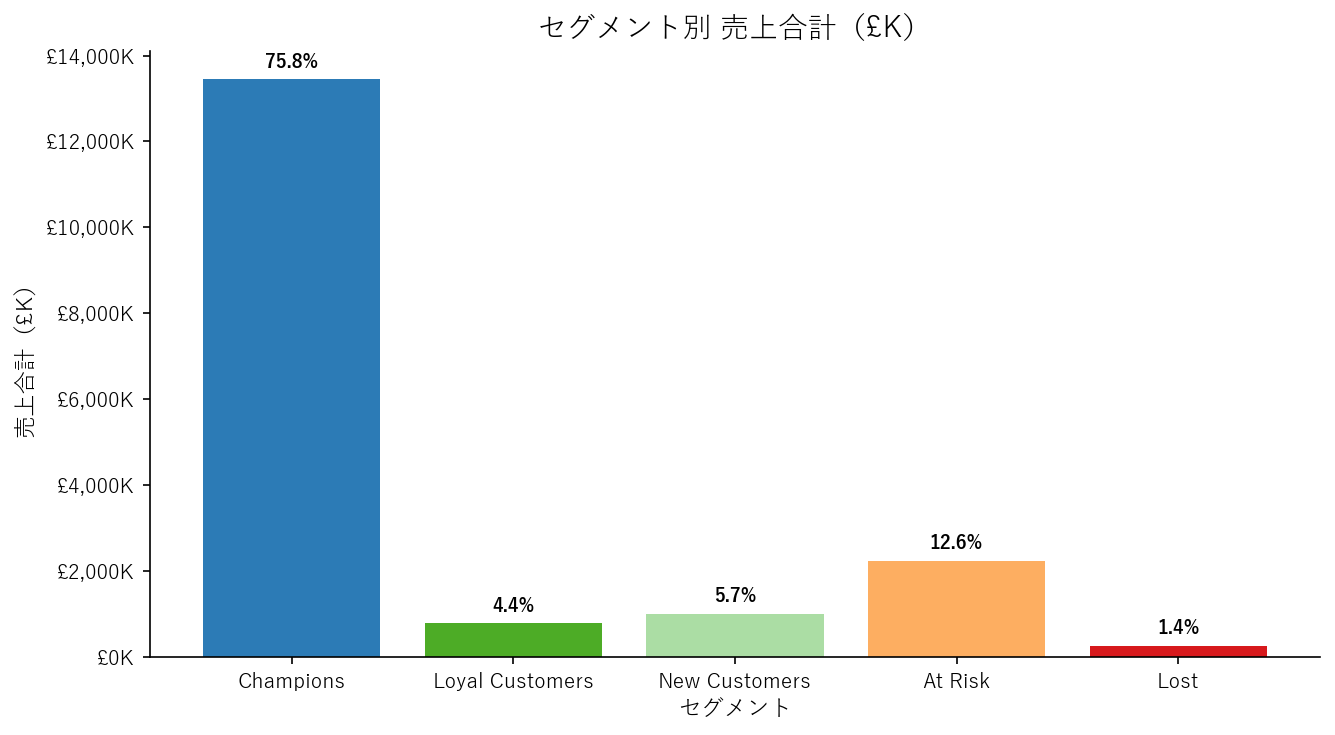

In [6]:
rev_by_seg = rfm.groupby('Segment')['Monetary'].sum().reindex(seg_order, fill_value=0)
colors_bar = [SEGMENT_COLORS[s] for s in rev_by_seg.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rev_by_seg.index, rev_by_seg.values / 1000, color=colors_bar)
ax.set_title('セグメント別 売上合計（£K）', fontsize=14)
ax.set_xlabel('セグメント')
ax.set_ylabel('売上合計（£K）')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))

total_rev = rev_by_seg.sum()
for bar, val in zip(bars, rev_by_seg.values):
    pct = val / total_rev * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_rev / 1000 * 0.01,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/charts/rfm_revenue_by_segment.png', bbox_inches='tight')
plt.show()

## Step 6 — RFM Heatmap (Score Profile per Segment)

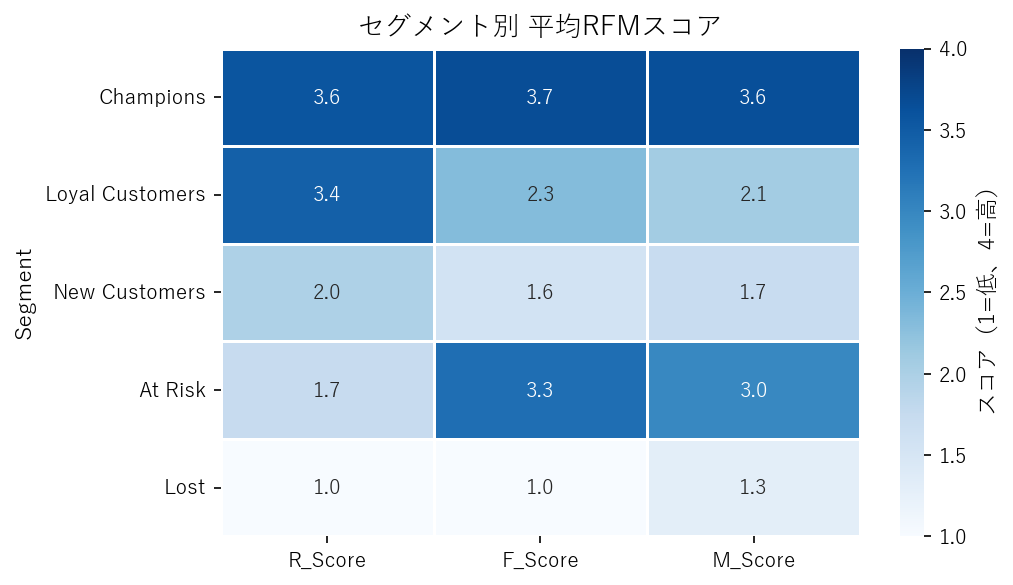

In [7]:
heatmap_data = rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']].mean()
heatmap_data = heatmap_data.reindex(seg_order)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Blues',
            vmin=1, vmax=4, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'スコア（1=低、4=高）'})
ax.set_title('セグメント別 平均RFMスコア', fontsize=13)
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../output/charts/rfm_heatmap.png', bbox_inches='tight')
plt.show()

---

## Key Findings & Recommended Actions

---

### アクションテーブル（セグメント別推奨アクション）

| セグメント | 特徴 | 推奨アクション |
|---|---|---|
| **Champions**（最優良顧客） | 最近購入、頻度高、金額大 | VIPロイヤリティ特典を提供。先行セール・新商品の優先案内。このセグメントの離脱は売上に直結するため、最優先でケア。 |
| **Loyal Customers**（優良顧客） | 継続購入・関与度高 | ポイントプログラムや定期購入割引を提案。アップセル・クロスセルの最有力候補。 |
| **At Risk**（離反リスク） | 過去は頻繁に購入したが最近購入なし | 「お久しぶりです」メールや限定割引クーポンを送付。放置すれば「Lost」に転落する可能性が高い。 |
| **Lost**（休眠顧客） | 購入から長期間経過・頻度低 | 再獲得コストを見極めた上で、高額割引のウィンバックキャンペーンを実施。費用対効果が低い場合はリスト管理に留める。 |
| **New Customers**（新規顧客） | 初回または少数回購入 | 二度目の購入を促すフォローアップメール（購入後7日以内）。初回購入体験の品質が長期LTVを決定する。 |

---

### Summary in English

1. **Champions generate disproportionate revenue** relative to their customer count. Any churn from this segment has an outsized impact on annual revenue — protect them first.
2. **At-Risk customers represent recoverable revenue** — they have proven purchase history but have gone quiet. A time-limited re-engagement offer (within 30 days of identifying them) has the highest chance of recovery.
3. **New Customers are the future pipeline** — their second purchase is the most important conversion event. Automate a post-purchase follow-up sequence and track 90-day repeat purchase rate as a leading KPI.
4. **Refresh this analysis monthly** — segments are not static. A Champion today can become At-Risk within 60 days without intervention.